In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install matplotlib tensorflow-datasets ipywidgets

In [4]:
#bringing in fashion mnist dataset
import tensorflow_datasets as tfds
#bringing in matplotlib for visualization
from matplotlib import pyplot as plt

In [5]:
#using the tensorflow dataset api to bring in the data source
#split tells that we only want the training part
ds=tfds.load('fashion_mnist',split='train')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

2026-03-16 17:18:41.238548: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773681521.456733     119 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773681521.516899     119 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773681522.013776     119 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773681522.013819     119 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773681522.013821     119 computation_placer.cc:177] computation placer alr

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

...

I0000 00:00:1773681544.575717      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773681544.581599      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.ZPUUTO_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.ZPUUTO_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.


In [9]:
#type of this  dataset is  prefetched component , we need to convert it to numpy as array
type(ds)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [10]:
#converting the prefected component to a numpy as array
ds.as_numpy_iterator().next()

{'image': array([[[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [ 18],
         [ 77],
         [227],
         [227],
         [208],
         [210],
         [225],
         [216],
         [ 85],
         [ 32],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],
 
        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [ 61],
         [100],
         [ 97],
         [ 80],
         [ 57],
         [117],
         [227],
         [238],
         [115],
         [ 49],
         [ 78],
         [106],
         [108],
         [ 71],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],
 
        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         

In [11]:
#so what we got is a dictionary , we only need the image
ds.as_numpy_iterator().next()['image']

array([[[  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [ 18],
        [ 77],
        [227],
        [227],
        [208],
        [210],
        [225],
        [216],
        [ 85],
        [ 32],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0]],

       [[  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [ 61],
        [100],
        [ 97],
        [ 80],
        [ 57],
        [117],
        [227],
        [238],
        [115],
        [ 49],
        [ 78],
        [106],
        [108],
        [ 71],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0]],

       [[  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [ 81],
        [105],
        [ 80],
        [ 69],
      

2)Building Dataset and Visualizing dataset


In [12]:
#doing some data transformation
import numpy as np

In [13]:
# setting up connection aka iterator to iterate over the pipeline
dataiterator=ds.as_numpy_iterator()

In [14]:
#each time we run this cell we get a different image
#getting data out of the pipeline
np.squeeze(dataiterator.next()['image']).shape

(28, 28)

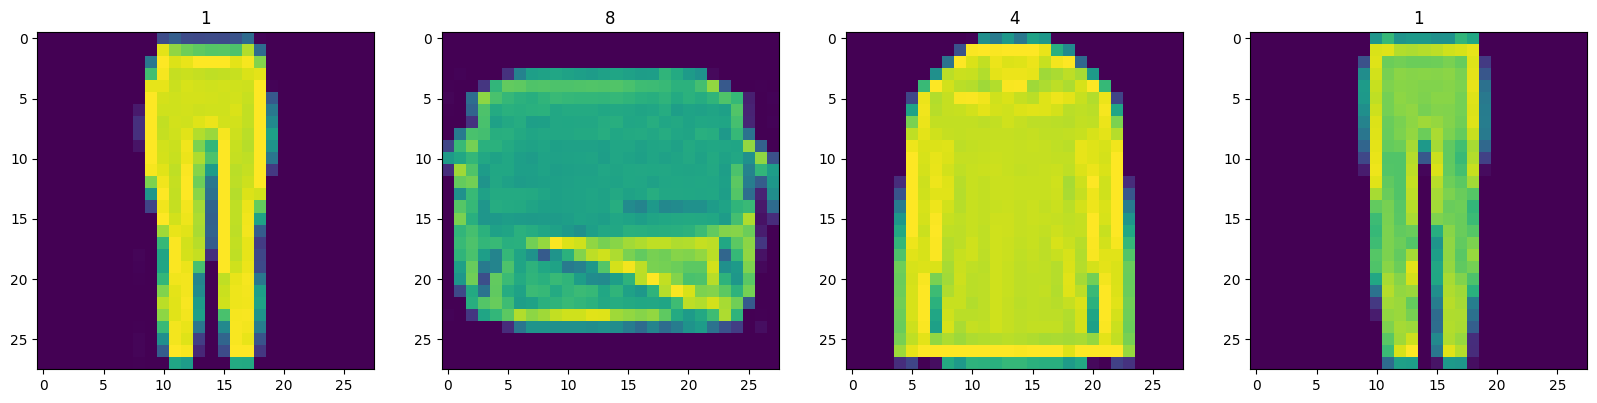

In [15]:
#plotting subplots of  4 images
#in below line we are setting up the format of the subplot
fig,ax=plt.subplots(ncols=4,figsize=(20,20))
#iterating over the pipeline 4 times to get the 4 images
for idx in range(4):
  #in below line of code i am grabbing image and label
  #when we get sample , what we get is image along with the label
  sample=dataiterator.next()
  #below line of code is plotting the image using the specific subplot
  ax[idx].imshow(np.squeeze(sample['image']))
  #appending image label as the plot title
  ax[idx].title.set_text(sample['label'])

In [16]:
#this function scales and returns images
def scale_images(data):
  image=data['image']
  return image/255

In [17]:
#reloading the dataset although it is completely optional
ds = tfds.load('fashion_mnist',split='train')
#map:running the datset through scale_images preprocessing step
ds=ds.map(scale_images)
#cache that batch
ds=ds.cache()
#shuffling
ds=ds.shuffle(60000)
#Batch into 128 images
ds=ds.batch(128)
#prefetching:reduces the likelihoood of bottlenecking
ds=ds.prefetch(64)


In [18]:
#128:batchsize
#28:height
#28:width
#1:grayscale
ds.as_numpy_iterator().next().shape

(128, 28, 28, 1)

3)Building the Neural Network:We will generate two models generative and discriminator.

In [19]:
#Importing modelling components
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,Reshape,LeakyReLU,Dropout,UpSampling2D

In [20]:
def build_generator():
    model = Sequential()

    # Takes in random values and reshapes it to 7x7x128
    # Beginnings of a generated image
    model.add(Dense(7*7*128, input_dim=128))
    model.add(LeakyReLU(0.2))
    model.add(Reshape((7,7,128)))

    # Upsampling block 1
    model.add(UpSampling2D())
    model.add(Conv2D(128, 5, padding='same'))
    model.add(LeakyReLU(0.2))

    # Upsampling block 2
    model.add(UpSampling2D())
    model.add(Conv2D(128, 5, padding='same'))
    model.add(LeakyReLU(0.2))

    # Convolutional block 1
    model.add(Conv2D(128, 4, padding='same'))
    model.add(LeakyReLU(0.2))

    # Convolutional block 2
    model.add(Conv2D(128, 4, padding='same'))
    model.add(LeakyReLU(0.2))

    # Conv layer to get to one channel
    model.add(Conv2D(1, 4, padding='same', activation='sigmoid'))

    return model

In [21]:
generator=build_generator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,155,137 (8.22 MB)

 Trainable params: 2,155,137 (8.22 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
#testing our generator
#generating 4 different random images
img = generator.predict(np.random.rand(4,128,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


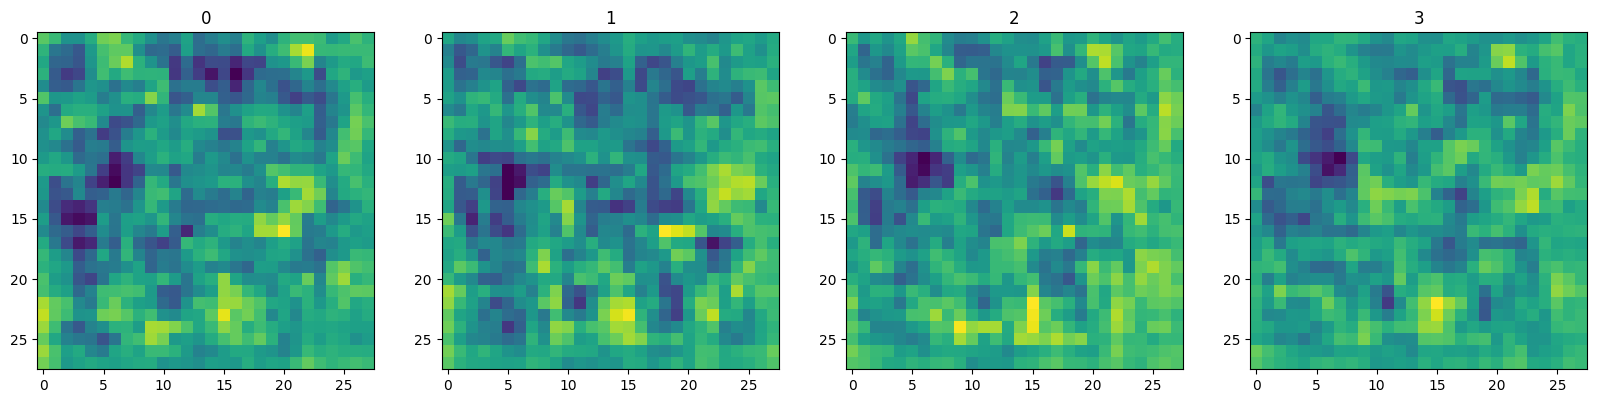

In [24]:
 #visualizing the 4 generated image
fig,ax=plt.subplots(ncols=4,figsize=(20,20))
#iterating over the pipeline 4 times to get the 4 images
for idx,img in enumerate(img):
  #below line of code is plotting the image using the specific subplot
  ax[idx].imshow(np.squeeze(img))
  #appending image label as the plot title
  ax[idx].title.set_text(idx)

In [26]:
def build_discriminator():
    model = Sequential()

    # First Conv Block
    model.add(Conv2D(32, 5, input_shape = (28,28,1)))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))

    # Second Conv Block
    model.add(Conv2D(64, 5))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))

    # Third Conv Block
    model.add(Conv2D(128, 5))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))

    # Fourth Conv Block
    model.add(Conv2D(256, 5))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))

    # Flatten then pass to dense layer
    model.add(Flatten())
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))

    return model

In [27]:
discriminator=build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 20, 20, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        36,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,113,345 (4.25 MB)

 Trainable params: 1,113,345 (4.25 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
discriminator.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step


array([[0.50752807],
       [0.50747675],
       [0.5074182 ],
       [0.50752175]], dtype=float32)

SETTING UP LOSS FUNCTIONS AND OPTIMIZERS FOR BOTH.

In [32]:
#Adam is going to be optimizer for both
from tensorflow.keras.optimizers import Adam
#Binary cross entropy is going to be loss function for both
from tensorflow.keras.losses import BinaryCrossentropy

In [33]:
g_opt=Adam(learning_rate=0.0001)
d_opt=Adam(learning_rate=0.00001)
g_loss=BinaryCrossentropy()
d_loss=BinaryCrossentropy()

In [34]:
#importing the base model clas to subclass our training step
from tensorflow.keras.models import Model

In [35]:
class FashionGAN(Model):
  def __init__(self,generator,discriminator,*args,**kwargs):
    super().__init__(*args,**kwargs)

    #create attributes for generator and discriminator

    self.generator=generator


    self.discriminator=discriminator


  def compile(self,g_opt,d_opt,g_loss,d_loss,*args,**kwargs):

    #compile with base class

    super().compile(*args,**kwargs)

    #create attributes for losses and optimizers
    self.g_opt = g_opt
    self.d_opt = d_opt
    self.g_loss = g_loss
    self.d_loss = d_loss


  def train_step(self,batch):

    real_images=batch
    fake_images=self.generator(tf.random.normal((128,128,1)),training=False)

    #training the discriminatoR
    #training is calculating gradients so we can use tf.GradientTape()
    with tf.GradientTape() as d_tape:
      #1)pass real and fake images to discriminator model
      yhat_real = self.discriminator(real_images,training=True)
      yhat_fake = self.discriminator(fake_images,training=True)
      #concatenating the two yhat_real and yhat_fake  , these are the  predictions from discriminator
      yhat_realfake=tf.concat([yhat_real,yhat_fake],axis=0)

      #2)create labels for real and fake images
      #real image has label 0 and fake image has label 1
      y_realfake=tf.concat([tf.zeros_like(yhat_real),tf.ones_like(yhat_fake)],axis=0)

      #3)add some noise to True outputs(this decreases the speed of discriminator)
      noise_real = 0.15*tf.random.uniform(tf.shape(yhat_real))
      noise_fake = -0.15*tf.random.uniform(tf.shape(yhat_fake))
      y_realfake += tf.concat([noise_real,noise_fake],axis=0)



      #4)calculate loss-Binary Cross
      total_d_loss=self.d_loss(y_realfake,yhat_realfake)

    #5)apply backpropogation
    #calculating gradient using backpropogration using the losses calculated in the loop
    dgrad=d_tape.gradient(total_d_loss,self.discriminator.trainable_variables)
    #optimizing
    self.d_opt.apply_gradients(zip(dgrad,self.discriminator.trainable_variables))

    #Train the generator
    with tf.GradientTape() as g_tape:
      #generate some new images
      gen_images = self.generator(tf.random.normal((128,128,1)),training=True)

      #create the predicted labels
      #we set training =False , because we do not want our discriminator to be learning when we are generating the images
      predicted_labels = self.discriminator(gen_images , training =False)


      #calculate loss
      total_g_loss=self.g_loss(tf.zeros_like(predicted_labels),predicted_labels)


    #apply backprop
    ggrad=g_tape.gradient(total_g_loss,self.generator.trainable_variables)
    self.g_opt.apply_gradients(zip(ggrad,self.generator.trainable_variables))

    return{"d_loss":total_d_loss,"g_loss":total_g_loss}

In [36]:
#create instance of  subclassed model
fashgan=FashionGAN(generator , discriminator)

In [37]:
#compile the model
fashgan.compile(g_opt,d_opt,g_loss,d_loss)

Building Callback(Optional)

In [38]:
import os
import tensorflow as tf  # Added this for tf.random
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.callbacks import Callback

class ModelMonitor(Callback):
    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim

        # COLAB FIX: Ensure the directory exists so the save doesn't fail
        if not os.path.exists('generated_images'):
            os.makedirs('generated_images')

    def on_epoch_end(self, epoch, logs=None):
        # Generate random vectors
        random_latent_vectors = tf.random.uniform((self.num_img, self.latent_dim, 1))

        # Predict using the generator
        generated_images = self.model.generator(random_latent_vectors)

        # Rescale and convert to numpy
        generated_images *= 255
        generated_images = generated_images.numpy()

        for i in range(self.num_img):
            img = array_to_img(generated_images[i])
            # Saving to the dedicated folder
            img.save(os.path.join('generated_images', f'generated_img_{epoch}_{i}.png'))

In [39]:

# recommended 2000 epochs
hist=fashgan.fit(ds,epochs=230,callbacks=[ModelMonitor()])

Epoch 1/230
469/469 ━━━━━━━━━━━━━━━━━━━━ 104s 169ms/step - d_loss: 0.5380 - g_loss: 1.0167
Epoch 2/230
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - d_loss: 0.3360 - g_loss: 2.4159
Epoch 3/230
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 140ms/step - d_loss: 0.2781 - g_loss: 2.6456
Epoch 4/230
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - d_loss: 0.2742 - g_loss: 2.6936
Epoch 5/230
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 142ms/step - d_loss: 0.2719 - g_loss: 2.6942
Epoch 6/230
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - d_loss: 0.2709 - g_loss: 2.6850
Epoch 7/230
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - d_loss: 0.2699 - g_loss: 2.6823
Epoch 8/230
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - d_loss: 0.2696 - g_loss: 2.6829
Epoch 9/230
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - d_loss: 0.2686 - g_loss: 2.6875
Epoch 10/230
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - d_loss: 0.2683 - g_loss: 2.6976
Epoch 11/230
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - d_loss: 0.2687 - g_loss: 2.7106
Epoch 1

Testing Generator

In [40]:
imgs=generator.predict(tf.random.normal((16,128,1)))
imgs

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[[[0.0000000e+00],
         [0.0000000e+00],
         [0.0000000e+00],
         ...,
         [0.0000000e+00],
         [0.0000000e+00],
         [0.0000000e+00]],

        [[0.0000000e+00],
         [0.0000000e+00],
         [0.0000000e+00],
         ...,
         [0.0000000e+00],
         [0.0000000e+00],
         [0.0000000e+00]],

        [[0.0000000e+00],
         [0.0000000e+00],
         [0.0000000e+00],
         ...,
         [0.0000000e+00],
         [0.0000000e+00],
         [0.0000000e+00]],

        ...,

        [[0.0000000e+00],
         [0.0000000e+00],
         [0.0000000e+00],
         ...,
         [0.0000000e+00],
         [0.0000000e+00],
         [0.0000000e+00]],

        [[5.7478070e-28],
         [0.0000000e+00],
         [0.0000000e+00],
         ...,
         [0.0000000e+00],
         [0.0000000e+00],
         [0.0000000e+00]],

        [[9.8388221e-28],
         [0.0000000e+00],
         [0.0000000e+00],
         ...,
         [0.0000000e+00],
        

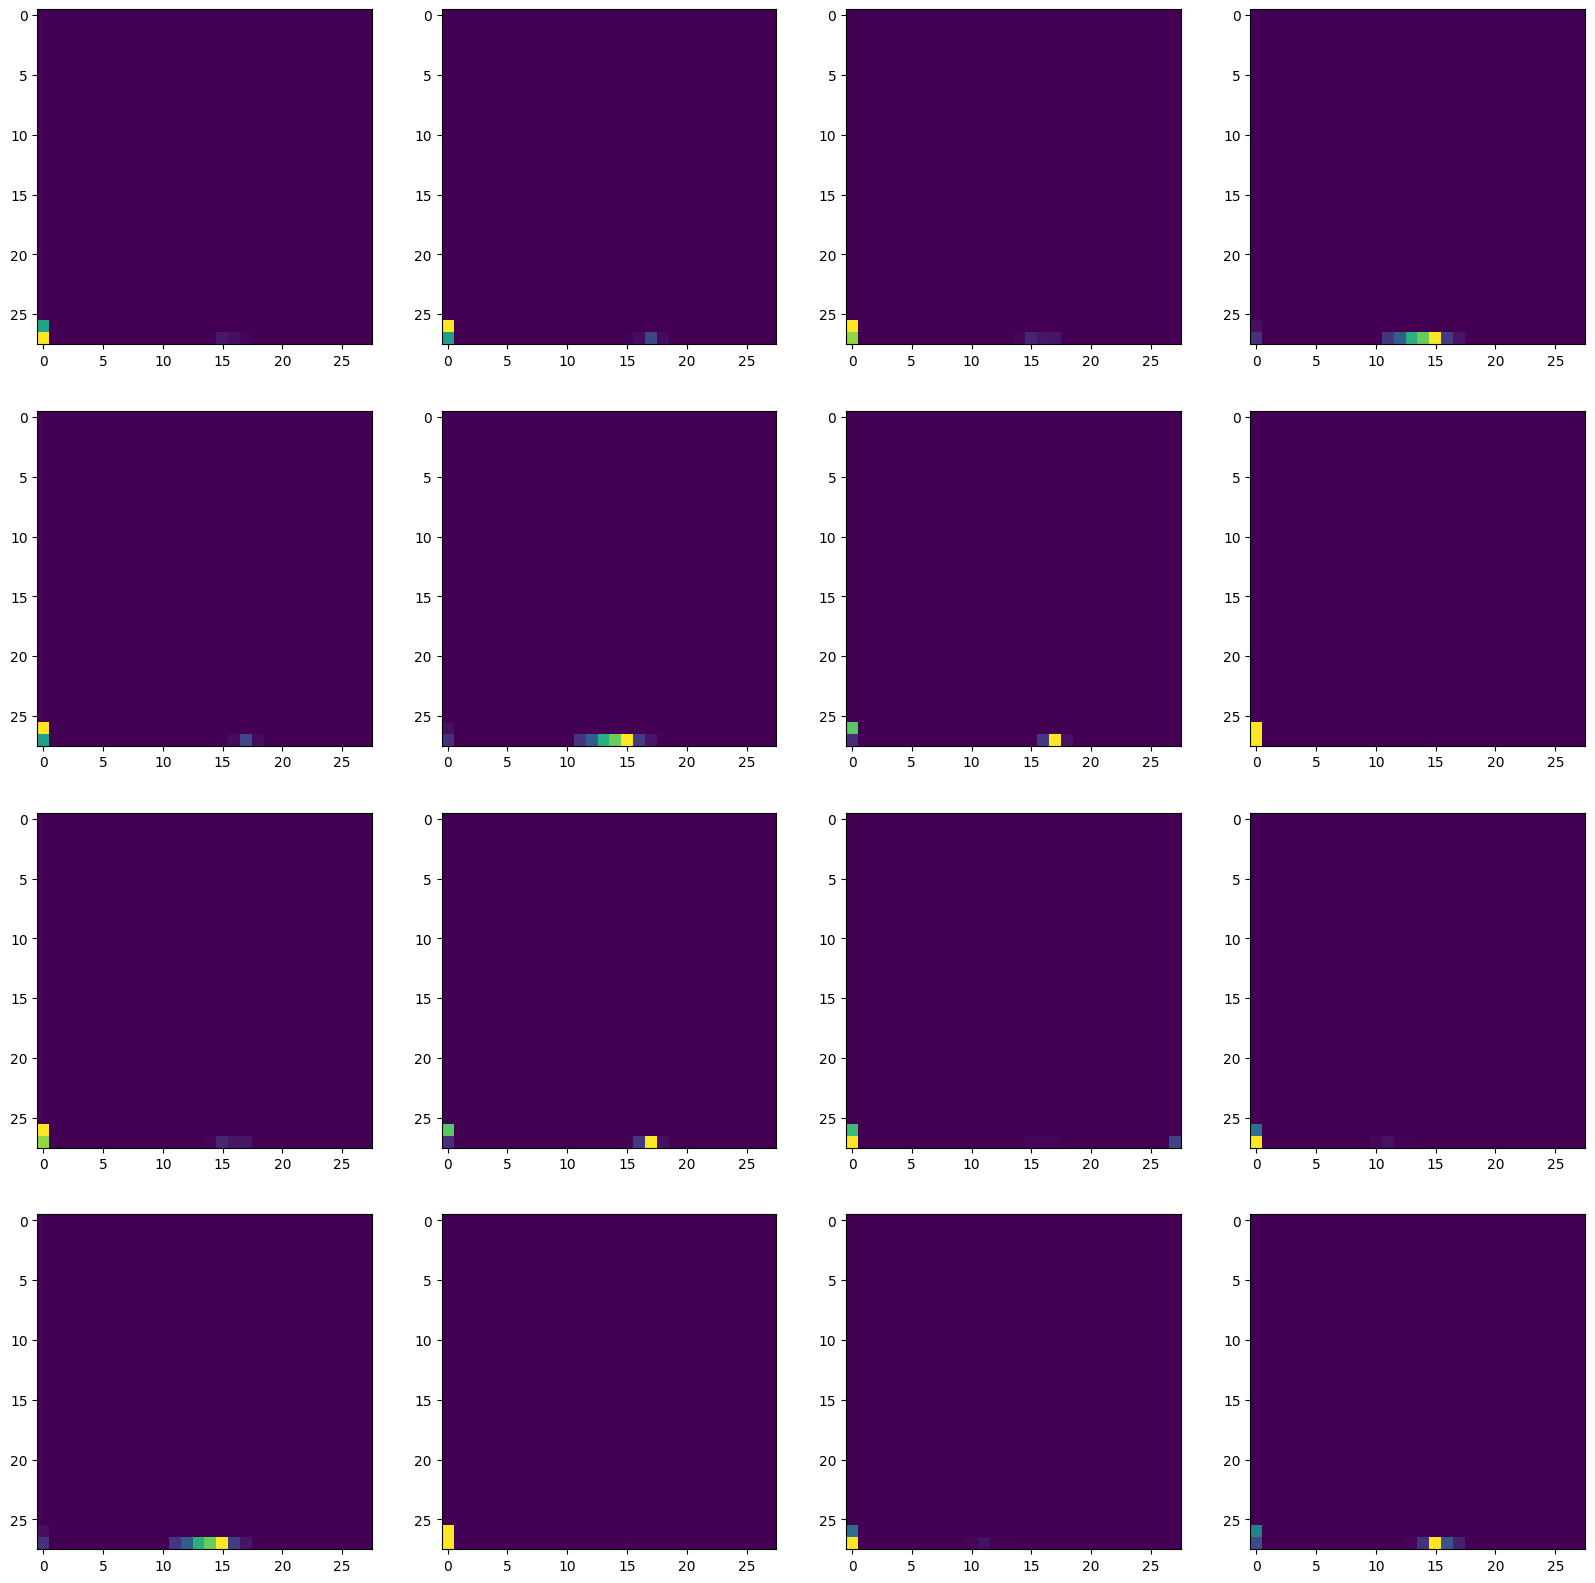

In [41]:
#visualizing the random generated images
fig,ax=plt.subplots(ncols=4,nrows=4,figsize=(20,20))
for r in range(4):
  for c in range(4):
    ax[r][c].imshow(imgs[(r+1)*(c+1)-1])